<a href="https://colab.research.google.com/github/orianacuzzi/TripleTen/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
print("\nInformación del dataset 'plans':")
plans.info()


Información del dataset 'plans':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
print("\nInformación del dataset 'users':")
users.info()


Información del dataset 'users':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
print("\nInformación del dataset 'usage':")
usage.info()


Información del dataset 'usage':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
print("Nulos en 'users':")
print(users.isna().sum())

print("\nProporción de nulos en 'users':")
print(users.isna().mean())

Nulos en 'users':
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de nulos en 'users':
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
print("\nNulos en 'usage':")
print(usage.isna().sum())

print("\nProporción de nulos en 'usage':")
print(usage.isna().mean())


Nulos en 'usage':
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de nulos en 'usage':
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?
  
- users:

city (11.7%) → proporción moderada de nulos.
👉 Acción: investigar si se puede recuperar (por ejemplo, de otras fuentes); si no, imputar o dejar como "Unknown".
churn_date (88.35%) → proporción muy alta de nulos.
👉 Acción: no eliminar, ya que probablemente los nulos indican usuarios activos (no han cancelado); convertir en variable binaria

usage:

date (0.125%) → proporción muy baja de nulos.
👉 Acción: imputación simple o eliminación de filas (impacto mínimo).
duration (55.19%) → alta proporción de nulos.
👉 Acción: no imputar directamente; analizar relación con type (ej. puede aplicar solo a llamadas).
length (44.74%) → alta proporción de nulos.
👉 Acción: similar a duration, probablemente depende del tipo de uso (ej. mensajes); analizar antes de imputar.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
users[['user_id', 'age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id`Presenta valores entre 10000 y 13999, lo cual es consistente con identificadores únicos. La media y los percentiles siguen una distribución uniforme, sin valores negativos ni extremos. No se detectan valores inválidos ni sentinels en esta columna.
- La columna `age` Aunque la mayoría de los valores están en un rango razonable (entre 32 y 79 años según los percentiles), el valor mínimo es -999, lo cual no es una edad válida. Esto indica claramente la presencia de un sentinel usado para representar datos faltantes o incorrectos.
Además, la desviación estándar es muy alta (123), lo cual también sugiere la presencia de valores atípicos como este.

In [ ]:
usage[['id', 'user_id']].describe()

,id,user_id
count,40000.00000,40000.000000
mean,20000.50000,12002.405975
std,11547.14972,1157.279564
min,1.00000,10000.000000
25%,10000.75000,10996.000000
50%,20000.50000,12013.000000
75%,30000.25000,13005.000000
max,40000.00000,13999.000000


- Las columnas `id` y `user_id`en el dataset usage son consistentes y no presentan problemas de calidad de datos.
- En las columnas no se observan valores negativos, ceros ni valores extremos fuera de rango, por lo que no hay evidencia de valores inválidos o sentinels en estas columnas.

In [ ]:

# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"Columna: {col}")
    print(users[col].value_counts())
    print()



Columna: city
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Columna: plan
Basico     2595
Premium    1405
Name: plan, dtype: int64



- La columna `city` aparece un valor "?" con 96 registros, lo cual indica un sentinel usado para representar datos faltantes o desconocidos. Este valor debe ser tratado (por ejemplo, reemplazándolo por NaN).
- La columna `plan` Los valores son consistentes, no hay categorías extrañas ni indicios de valores inválidos o sentinels.

In [ ]:
# explorar columna categórica de usage
usage['type'].value_counts() # completa el código

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` Ambas son coherentes con el tipo de datos esperados (mensajes y llamadas). No se observan valores extraños como "?", "unknown" u otros que indiquen datos faltantes.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?
- age (users)
Sentinel detectado: -999
Problema: Edad negativa, imposible para un usuario real.
Acción sugerida: Reemplazar el sentinel por NaN para indicar dato faltante, y si se requiere, imputar con la media, mediana o eliminar el registro según el análisis.
city (users)
Sentinel detectado: "?"
Problema: Ciudad desconocida o no registrada.
Acción sugerida: Reemplazar "?" por NaN y decidir si imputar con la ciudad más frecuente o dejar como faltante según el análisis.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:

# Convertir a fecha la columna `reg_date` de users
users['reg_date'] =pd.to_datetime(users['reg_date'])

In [ ]:

# Convertir a fecha la columna `date` de usage
usage['date'] =  pd.to_datetime(usage['date'], errors='coerce')


In [ ]:
users['reg_date'].dt.year.value_counts()


2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, La mayoría de los registros corresponden a los años 2022, 2023 y 2024, lo cual es consistente con usuarios recientes.
Hay 40 registros con el año 2026, que es un valor inválido (aún no ha ocurrido). Esto indica un sentinel o error de ingreso de datos.

In [ ]:
usage['date'].dt.year.unique()

array([2024.,   nan])

En `date`, La mayoría de los registros tienen el año 2024, que es consistente.
Los NaN indican valores faltantes, es decir, registros don

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?
- Columna reg_date (users)

Problema detectado: Aparecen 40 registros con el año 2026, que aún no ha ocurrido → valor fuera de rango / sentinel.
Acción recomendada:
Reemplazar estos valores por NaT para indicar dato faltante, o
Corregir la fecha si se conoce la información correcta.

Columna date (usage)

Problema detectado: No hay años imposibles, todos los registros válidos corresponden a 2024.
Valores faltantes: Hay algunos NaN en la columna → funcionan como sentinels.
Acción recomendada:
Dependiendo del análisis, se pueden eliminar estos registros o imputar fechas si se dispone de información adicional

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_media = users.loc[users['age'] != -999, 'age'].mean()

# Reemplazar -999 por la media
users['age'] = users['age'].replace(-999, age_media)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.137896
std        17.689912
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
import numpy as np

# Reemplazar "?" por NaN
users['city'] = users['city'].replace('?', np.nan)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [ ]:
import pandas as pd

# Mantener solo fechas <= hoy, reemplazar el resto por NaT
users['reg_date'] = users['reg_date'].where(users['reg_date'] <= pd.Timestamp.today(), pd.NaT)

# Verificar cambios
users['reg_date'].value_counts(dropna=False)

NaT                              40
2023-03-31 06:21:20.120030008     1
2024-06-20 09:50:54.463615904     1
2022-05-22 00:23:45.956489122     1
2022-04-23 06:22:24.936234060     1
                                 ..
2022-07-29 04:44:06.661665416     1
2022-02-22 00:36:43.750937734     1
2022-10-31 09:22:49.242310580     1
2022-09-24 16:46:48.702175544     1
2022-03-28 12:38:20.975243811     1
Name: reg_date, Length: 3961, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.


**Instrucciones:**

- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
usage["duration"].isna().groupby(usage["type"]).mean()

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [ ]:

usage["length"].isna().groupby(usage["type"]).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Los nulos en duration y length son Missing Not At Random (MNAR), ya que su ausencia está completamente explicada por la variable type. No se trata de un problema de calidad de datos, sino de la naturaleza del dataset.

Recomendación:

No imputar estos valores. En su lugar:

Mantener los nulos como están, o
Analizar cada tipo (call y text) por separado.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",        # Total de mensajes por usuario
    "is_call": "sum",       # Total de llamadas por usuario
    "duration": "sum",      # Duración total de llamadas
    "length": "sum"         # Longitud total de mensajes
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration,length
0,10000,7,3,23.70,258.0
1,10001,5,10,33.18,226.0
2,10002,5,2,10.74,225.0


In [ ]:

usage_agg = usage_agg. rename(columns={
     "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})

# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,length
0,10000,7,3,23.70,258.0
1,10001,5,10,33.18,226.0
2,10002,5,2,10.74,225.0


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,length
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,258.0
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,226.0
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,225.0
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,530.0
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,229.0


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
usage_agg.describe()


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,length
count,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000
mean,11999.729432,5.524381,4.478120,23.317054,288.128032
std,1154.898108,2.358416,2.144238,18.168095,180.906841
min,10000.000000,0.000000,0.000000,0.000000,0.000000
25%,10999.500000,4.000000,3.000000,11.120000,184.000000
50%,12000.000000,5.000000,4.000000,19.780000,268.000000
75%,12999.500000,7.000000,6.000000,31.415000,361.000000
max,13999.000000,17.000000,15.000000,155.690000,2028.000000


In [ ]:
user_profile["plan"].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

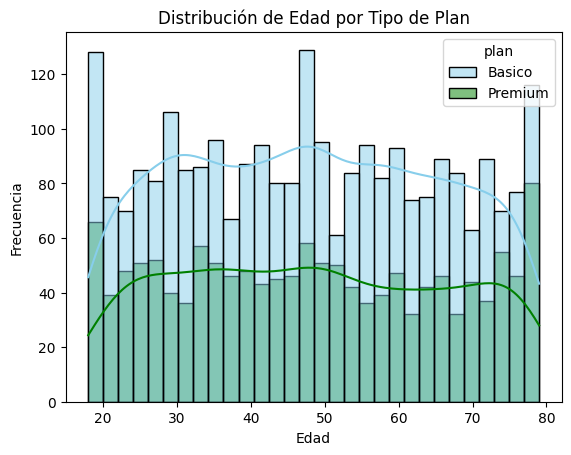

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(
   data=user_profile,
    x="age",
    hue="plan",
    palette=["skyblue", "green"],
    bins=30,
    kde=True
)
plt.title("Distribución de Edad por Tipo de Plan")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

plt.show()

💡Insights:
No se observa un patrón claro entre la edad y el tipo de plan. Tanto los usuarios Básico como Premium están distribuidos de manera bastante similar a lo largo de todas las edades.
a distribución de la edad es aproximadamente:

Simétrica (casi uniforme)
No presenta un sesgo claro ni a la derecha ni a la izquierda
Tampoco hay picos pronunciados (no es normal clásica), sino bastante plana.

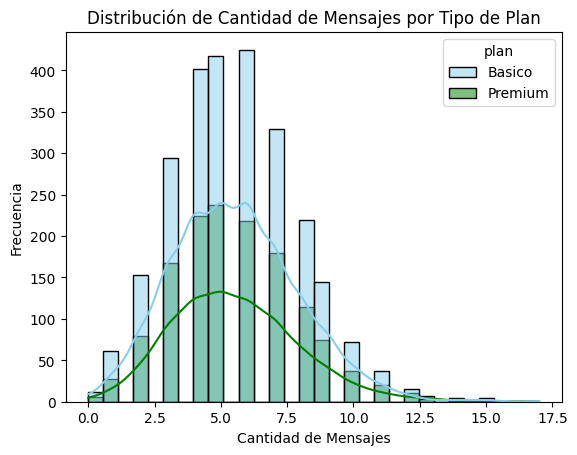

In [ ]:
# Histograma de cantidad de mensajes por tipo de plan
sns.histplot(
     data=user_profile,
    x="cant_mensajes",
    hue="plan",
    palette=["skyblue", "green"],
    bins=30,
    kde=True
)

plt.title("Distribución de Cantidad de Mensajes por Tipo de Plan")
plt.xlabel("Cantidad de Mensajes")
plt.ylabel("Frecuencia")

plt.show()

💡Insights:
Dentro del plan Básico, hay una mayor proporción de usuarios que envían entre 3 y 7 mensajes, con un pico alrededor de 5 mensajes. En contraste, los usuarios del plan Premium tienden a enviar menos mensajes en general, con frecuencias más bajas y una distribución más concentrada hacia valores menores.
El plan Básico concentra más usuarios con un volumen moderado de mensajes.
El plan Premium tiene menos usuarios y tiende a mensajes en menor cantidad.
Esta diferencia podría reflejar distintos patrones de uso o incentivos asociados a cada plan.

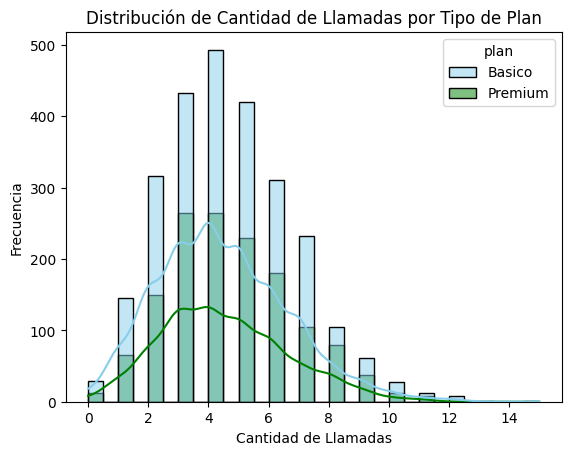

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Histograma de cantidad de llamadas por tipo de plan
sns.histplot(
  data=user_profile,
    x="cant_llamadas",
    hue="plan",
    palette=["skyblue", "green"],
    bins=30,
    kde=True
)

plt.title("Distribución de Cantidad de Llamadas por Tipo de Plan")
plt.xlabel("Cantidad de Llamadas")
plt.ylabel("Frecuencia")

plt.show()


💡Insights:
Dentro del plan Básico, hay una mayor proporción de usuarios que realizan entre 3 y 6 llamadas, con un pico alrededor de 4 llamadas. Por otro lado, los usuarios del plan Premium tienden a hacer menos llamadas en general, con frecuencias más bajas y una concentración hacia valores menores.
El plan Básico concentra más usuarios con un número moderado de llamadas.
El plan Premium tiene menos usuarios que hacen llamadas, y en menor cantidad.
Esto podría reflejar diferencias en comportamiento o en incentivos de cada plan.

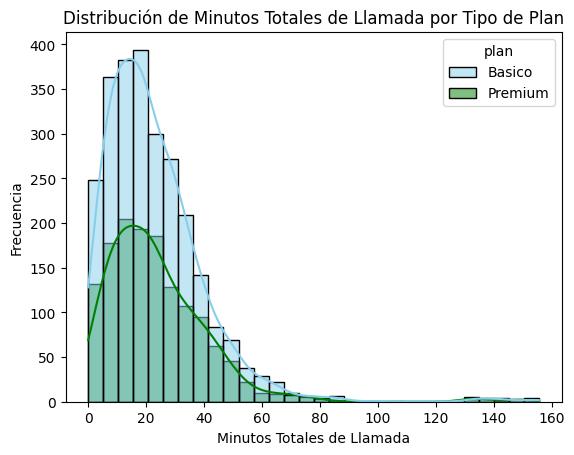

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Histograma de minutos totales de llamada por tipo de plan
sns.histplot(
  data=user_profile,
    x="cant_minutos_llamada",
    hue="plan",
    palette=["skyblue", "green"],
    bins=30,
    kde=True
)

plt.title("Distribución de Minutos Totales de Llamada por Tipo de Plan")
plt.xlabel("Minutos Totales de Llamada")
plt.ylabel("Frecuencia")

plt.show()


💡Insights:
- Sesgada a la derecha (asimétrica positiva).
La concentración máxima está cerca de 0-20 minutos, con una cola extendida hasta 160 minutos, típica de datos de uso telefónico donde predominan consumos bajos y valores atípicos altos.
El Plan Básico tiene mayor frecuencia en 0-40 minutos (pico ~20), con cola más pronunciada hacia los extremos (>100 minutos).
Los usuarios básicos tienden a bajo consumo, pero incluyen casos atípicos de uso intensivo. El Plan Premium tiene un pico en ~10-30 minutos, dispersión más uniforme pero aún sesgada.
Los usuarios Premium muestran consumos bajos similares, aunque con menos extremos que Básico. No existe patrón claro de mayor uso por plan.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

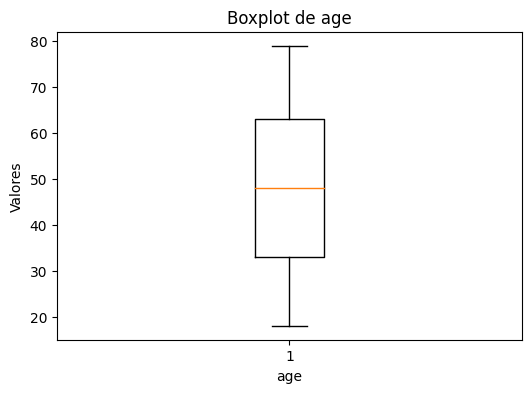

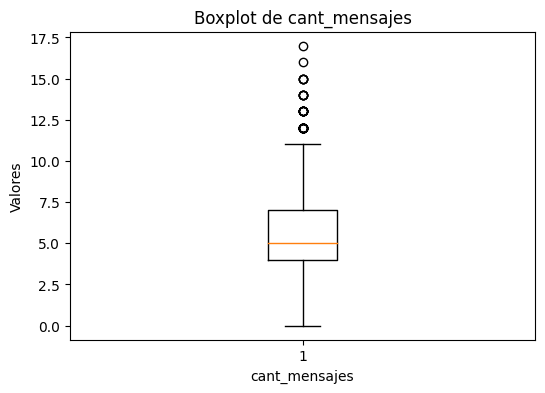

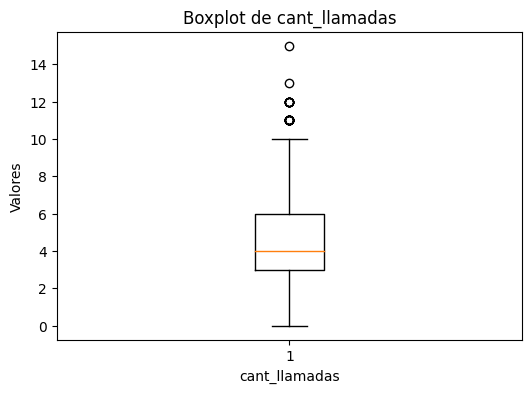

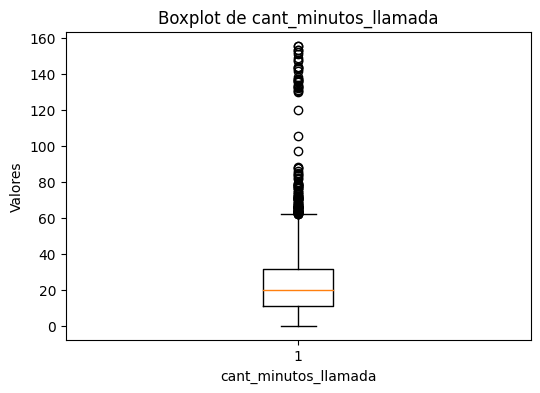

In [ ]:


import matplotlib.pyplot as plt

# Lista de columnas numéricas
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# Loop para generar boxplots
for col in columnas_numericas:
    plt.figure(figsize=(6,4))  # crea una figura nueva en cada iteración
    plt.boxplot(user_profile[col].dropna())  # Cambiar df por user_profile
    plt.title(f'Boxplot de {col}')
    plt.xlabel(col)
    plt.ylabel('Valores')
    plt.show()


💡Insights:
- Age: no presenta outliers
- cant_mensajes: presenta outliers
- cant_llamadas: presenta outliers
- cant_minutos_llamada: presenta outliers

In [ ]:

columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

columnas_limites = {}

for col in columnas_numericas:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    columnas_limites[col] = (limite_inferior, limite_superior)

# Ver resultados
columnas_limites

{'age': (-12.0, 108.0),
 'cant_mensajes': (-0.5, 11.5),
 'cant_llamadas': (-1.5, 10.5),
 'cant_minutos_llamada': (-19.322500000000005, 61.8575)}

In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.137896,5.524381,4.478120,23.317054
std,17.689912,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes
 Sí hay outliers (17 > 11.5) MANTENER (en la mayoría de casos)
Por qué:
Es una variable de comportamiento (uso del usuario)
Es totalmente lógico que algunos usuarios envíen muchos más mensajes
No parece error (no hay valores absurdos como 1000)
cant_llamadas  MANTENER
Por qué:
Igual que antes: comportamiento real
15 llamadas no es un valor imposible
Puede indicar usuarios intensivos
Eliminar estos datos podría sesgar el análisis (perder usuarios intensivos)
cant_minutos_llamada
Hay outliers fuertes (muy por encima)
Análisis:
155 min ≈ 2.5 horas → posible, pero extremo
Mucho más alejado que en las otras variables
Opciones:
Opción A — Mantener (si es comportamiento real)
Usuarios que hablan mucho
Puede ser importante para negocio
Opción B — Tratar (RECOMENDADO)
Hacer capping (winsorizing)

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:

user_profile['grupo_uso'] = 'Alto uso'


user_profile.loc[
    (user_profile['cant_llamadas'] < 5) &
    (user_profile['cant_mensajes'] < 5),
    'grupo_uso'
] = 'Bajo uso'


user_profile.loc[
    (user_profile['cant_llamadas'] < 10) &
    (user_profile['cant_mensajes'] < 10),
    'grupo_uso'
] = 'Uso medio'

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,length,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,258.0,Uso medio
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,226.0,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,225.0,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,530.0,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,229.0,Uso medio


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
user_profile['grupo_edad'] = 'Adulto Mayor'

user_profile.loc[user_profile['age'] < 30, 'grupo_edad'] = 'Joven'

user_profile.loc[
    (user_profile['age'] >= 30) & (user_profile['age'] < 60),
    'grupo_edad'
] = 'Adulto'

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,length,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,258.0,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,226.0,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,225.0,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,530.0,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,229.0,Uso medio,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

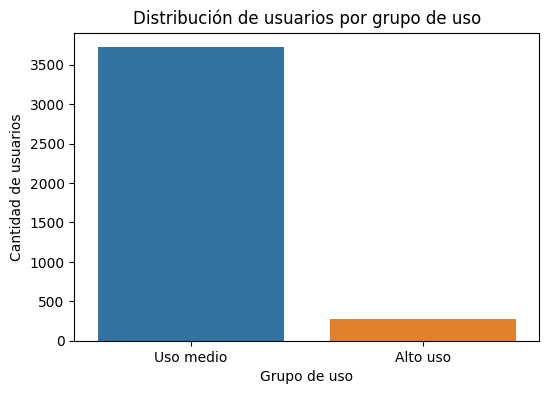

In [ ]:

plt.figure(figsize=(6,4))
sns.countplot(x='grupo_uso', data=user_profile)
plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()


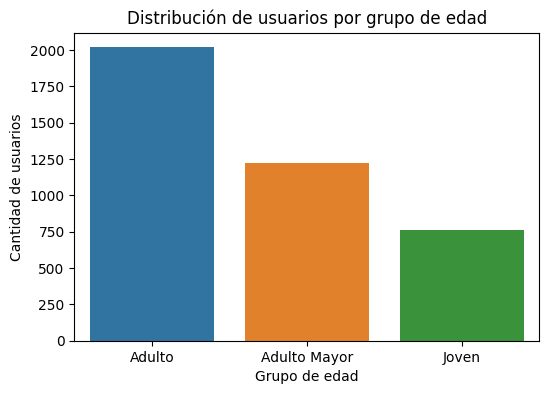

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='grupo_edad', data=user_profile)
plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
1. Valores nulos:

city: 11.7% (469 filas) - proporción moderada
churn_date: 88.35% (3,534 filas) - alta proporción (normal, indica usuarios activos)
date (usage): 0.125% (50 filas) - proporción mínima
duration: 55.19% (22,076 filas) - alta proporción (normal para mensajes)
length: 44.74% (17,896 filas) - alta proporción (normal para llamadas)
2. Valores sentinels:

age: -999 (sentinel para datos faltantes)
city: "?" (96 registros, 2.4% del total)
reg_date: 40 registros con año 2026 (1% del total)

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
- Por nivel de uso:

Uso medio: Mayoría de usuarios
Alto uso: Menor proporción
Bajo uso: Proporción intermedia
Por edad:

Adultos (30-60 años): Segmento más grande
Adultos mayores (60+ años): Segundo segmento
Jóvenes (<30 años): Segmento más pequeño
Comportamiento por plan:

Plan Básico (64.9%): Mayor volumen de usuarios, uso moderado de mensajes y llamadas
Plan Premium (35.1%): Menor volumen pero patrones de uso similares

- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
- Adultos con Uso Medio
Por qué son valiosos
Este grupo adultos entre 30 y 60 años con uso moderado de serviciossuele ser el segmento más numeroso. Aunque cada cliente individual genera menos ingresos que los heavy users, su volumen hace que su impacto agregado sea significativo para el negocio.
Este segmento es valioso porque:

Representa la estabilidad de la cartera de clientes.
Su uso regular (aunque no extremo) mantiene ingresos consistentes.
Son menos propensos a churn si sienten que los planes satisfacen sus necesidades diarias.
Usuarios de Alto Uso — Segmento Estratégico
 Por qué son valiosos
Estos clientes realizan muchas llamadas, envían muchos mensajes y acumulan minutos altos en comparación con la mayoría del resto. En telecom, los segmentos de alto uso tienden a generar gran parte de los ingresos recurrentes, especialmente si están en planes con mayor consumo.
Estos usuarios son importantes porque:

Aportan más ingresos por uso del servicio.
Tienen mayor probabilidad de convertirse en clientes leales o voceros de la marca si están satisfechos.
Su comportamiento de consumo puede guiar mejoras en los planes premium o en beneficios adicionales.

- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- cant_mensajes: Máximo 17 vs límite 11.5
cant_llamadas: Máximo 15 vs límite 10.5
cant_minutos_llamada: Máximo 155.7 vs límite 61.9
Que haya usuarios con más mensajes o llamadas que el límite típico no necesariamente es malo.
Estos valores no solo son datos “raros”: pueden representar usuarios intensivos que aportan mucho valor a tu negocio. Por ejemplo:

usuarios que envían muchos mensajes podrían ser clientes leales o heavy users
más minutos de llamada podrían indicar uso frecuente del servicio
En análisis de datos, los outliers pueden mostrar comportamientos reales pero no comunes que valen la pena estudiar.
Esto implica que:

Si basas decisiones únicamente en medias, puedes malinterpretar el uso real de la mayoría de usuarios.
Es recomendable usar métricas robustas (como la mediana) o hacer segmentaciones por grupos para un mejor entendimiento



- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
Planes ligeros para “Bajo uso”

Tarifas económicas con pocos minutos y mensajes
Ideal para clientes sensibles al precio o que solo usan lo básico
Reduce la probabilidad de abandono al ofrecerles justo lo que necesitan

Planes estándar para “Uso medio”

Equilibrio entre minutos, mensajes y posiblemente datos o servicios adicionales
Este segmento suele ser el núcleo de la base de clientes

Planes premium o ilimitados para “Alto uso”

Ofertas con muchos minutos/textos y opciones de datos generosas
Posible incluir beneficios adicionales (prioridad en red, extras de entretenimiento)
La segmentación basada en uso tiende a mejorar satisfacción y retención.

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
Valores nulos significativos en columnas clave como duration y length, lo que puede afectar la interpretación de uso de llamadas y mensajes.
Uso de valores sentinel como -999 en edad y “?” en ciudad, indicadores de datos faltantes o incorrectos que requieren limpieza antes de análisis profundo.
Fechas atípicas en reg_date (año 2026) sugieren posibles errores o registros adelantados, que deben verificarse antes de su uso en análisis temporal.


🔍 **Segmentos por Edad**
Adultos (30–60 años): segmento más numeroso dentro de la base de clientes.
Adultos mayores (60+): segundo segmento más grande, con características de uso más moderadas.
Jóvenes (<30 años): menor representación, pero relevante para planes modernos o digitales.

📊 **Segmentos por Nivel de Uso**
Uso Medio: grupo mayoritario, consumidores regulares de llamadas y mensajes (uso equilibrado).
Alto Uso: menor proporción, pero con patrones de consumo mucho más intensivos.
Bajo Uso: segmento intermedio, con uso limitado de servicios básicos.


➡️ Esto sugiere que ...
El comportamiento de consumo no es homogéneo: hay diferencias claras entre segmentos por edad y nivel de uso, lo que indica que una estrategia universal de planes no está optimizada para todos los perfiles de cliente. Estos hallazgos muestran oportunidades para personalizar ofertas y retener mejor a segmentos críticos.

💡 **Recomendaciones**
Planes Premium dirigidos a Usuarios de Alto Uso: con más minutos y mensajes, posiblemente con beneficios añadidos que incentiven fidelidad.
Planes Intermedios para Uso Medio: equilibrados en oferta y precio, para maximizar retención de la mayoría del cliente.
Planes Económicos o básicos para Bajo Uso: enfocarse en simplicidad y bajo costo para evitar churn por precios altos.
Para jóvenes, incluir beneficios digitales, datos móviles o servicios modernos.
Para adultos mayores, énfasis en simplicidad, soporte y valor claro por precio.
Implementar estrategias de fidelización

Ofertas personalizadas basadas en comportamiento de uso y alertas inteligentes antes de sobrepasar límites, buscando mejorar la satisfacción y reducir rotación de clientes.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`